In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [4]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [5]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [6]:
X_class_train

array([[9.029e+00, 1.733e+01, 5.879e+01, ..., 1.750e-01, 4.228e-01,
        1.175e-01],
       [2.109e+01, 2.657e+01, 1.427e+02, ..., 2.903e-01, 4.098e-01,
        1.284e-01],
       [9.173e+00, 1.386e+01, 5.920e+01, ..., 5.087e-02, 3.282e-01,
        8.490e-02],
       ...,
       [1.429e+01, 1.682e+01, 9.030e+01, ..., 3.333e-02, 2.458e-01,
        6.120e-02],
       [1.398e+01, 1.962e+01, 9.112e+01, ..., 1.827e-01, 3.179e-01,
        1.055e-01],
       [1.218e+01, 2.052e+01, 7.722e+01, ..., 7.431e-02, 2.694e-01,
        6.878e-02]], shape=(455, 30))

In [7]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [8]:
X_class_train_scaled

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

In [9]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [10]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

In [11]:
# Create SVM classifier
svm = SVC(random_state=42)

In [12]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [13]:
# Start timing
start_time = time.time()


In [14]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf', 'poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this sp

In [15]:
# End timing
grid_time = time.time() - start_time

In [16]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 15.28 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [17]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [18]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)
grid_results.shape

(32, 23)

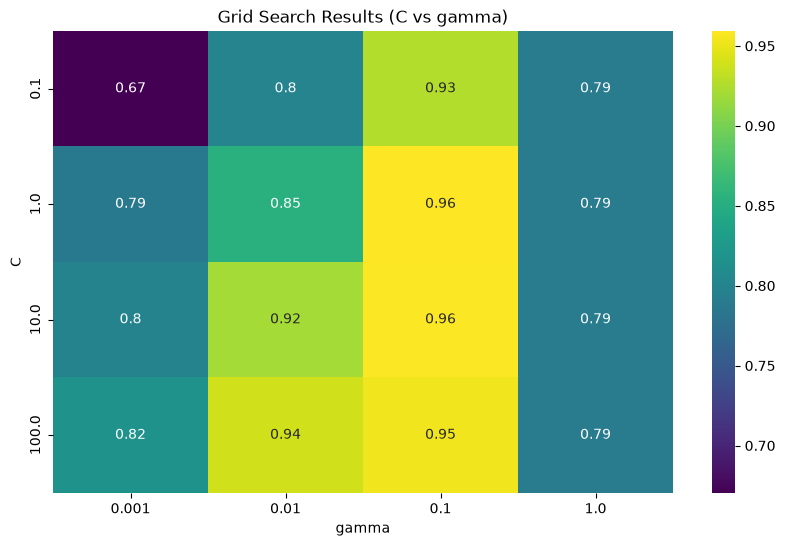

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [20]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [21]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [22]:
# Start timing
start_time = time.time()

In [23]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....001957DBF0510>, 'gamma': <scipy.stats....001957DD26150>, 'kernel': ['rbf', 'poly']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.

In [24]:
# End timing
random_time = time.time() - start_time

In [25]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 0.95 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [26]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [27]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456           15.283759
1  Random Search       0.971429       0.964912            0.947233


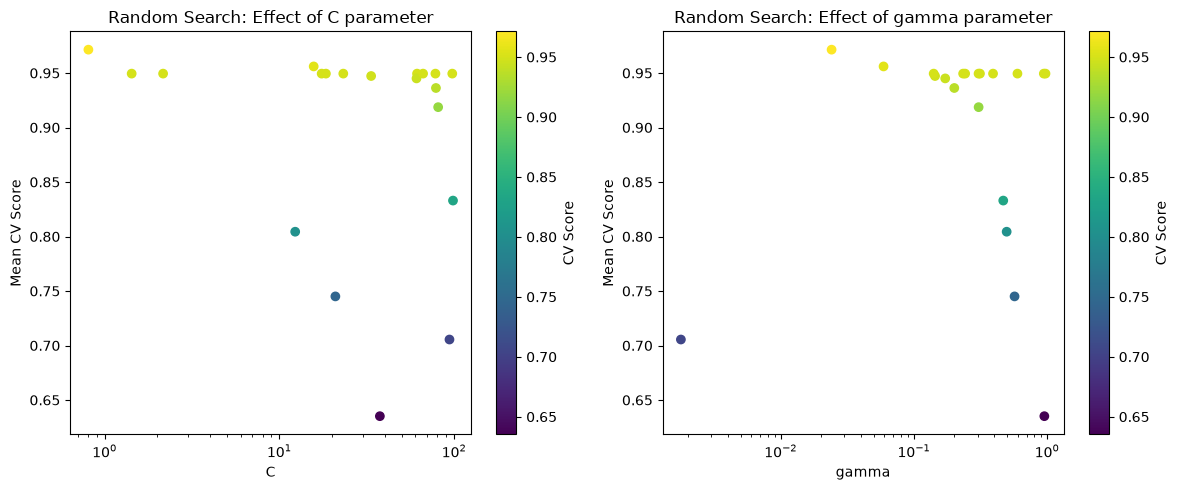

In [28]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [29]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

In [30]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [31]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [32]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [33]:
# Start timing
start_time = time.time()

In [34]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

,estimator,SVC(random_state=42)
,search_spaces,"{'C': Real(low=0.1,...m='normalize'), 'gamma': Real(low=0.00...m='normalize'), 'kernel': Categorical(c...), prior=None)}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,cv,5
,random_state,42
,return_train_score,True
,optimizer_kwargs,None
,fit_params,None
,n_points,1


In [35]:
# End timing
bayes_time = time.time() - start_time

In [36]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 14.26 seconds
Best parameters: OrderedDict([('C', 47.479208101335), ('gamma', 0.015041969444183602), ('kernel', 'rbf')])
Best cross-validation score: 0.9626


In [37]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [38]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456           15.283759
1          Random Search       0.971429       0.964912            0.947233
2  Bayesian Optimization       0.962637       0.956140           14.260584


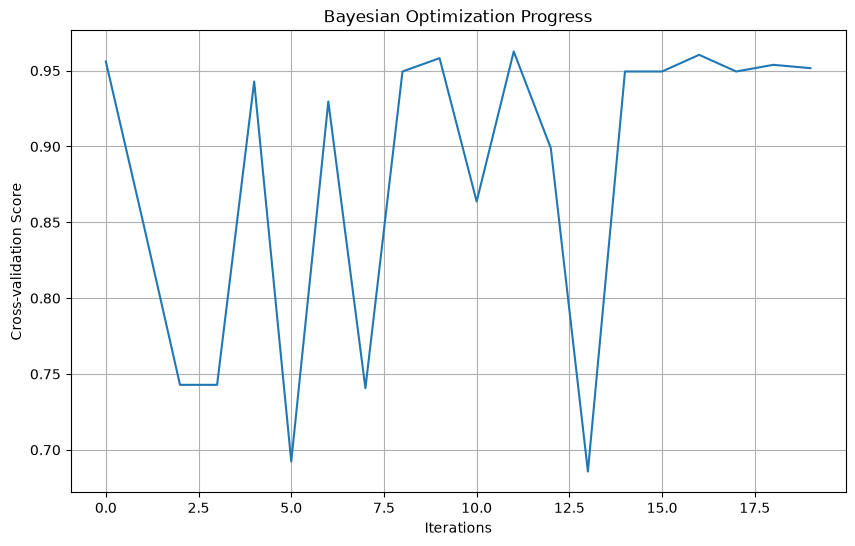

In [39]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [40]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [41]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': [1.0,'sqrt', 'log2', None]
}

In [42]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [43]:
# Start timing
start_time = time.time()

In [44]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': <scipy.stats....001957EEBE410>, 'regressor__max_features': [1.0, 'sqrt', ...], 'regressor__min_samples_leaf': <scipy.stats....001957F95C8D0>, 'regressor__min_samples_split': <scipy.stats....001957F2FE090>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For mul

In [45]:
# End timing
rf_random_time = time.time() - start_time

In [46]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 4.96 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [47]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test R² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test R² with optimal parameters: 0.4698


In [48]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

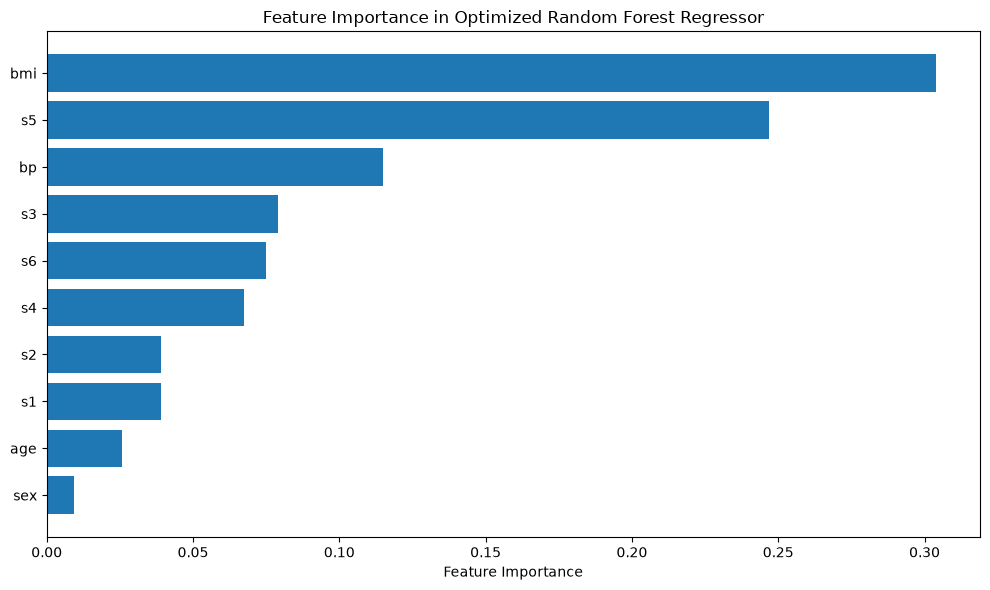

In [49]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [50]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    
    train_sizes, train_scores, test_scores = learning_curve(estimator, 
                                                            X, y, 
                                                            cv=cv, 
                                                            n_jobs=-1, 
                                                            train_sizes=train_sizes, 
                                                            scoring='accuracy')

    train_scores_mean ,train_scores_std = np.mean(train_scores, axis=1) , np.std(train_scores, axis=1)
    test_scores_mean , test_scores_std = np.mean(test_scores, axis=1) , np.std(test_scores, axis=1)
    

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [51]:
from sklearn.model_selection import learning_curve


In [52]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

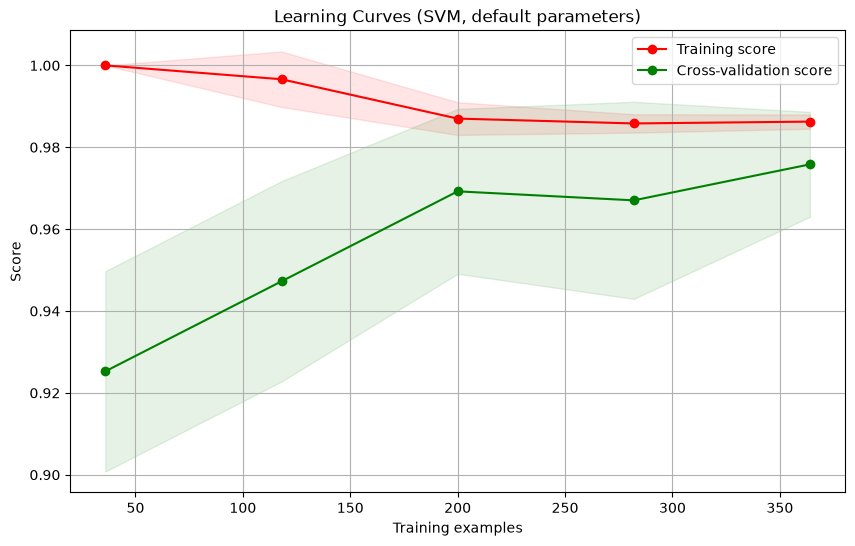

In [53]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

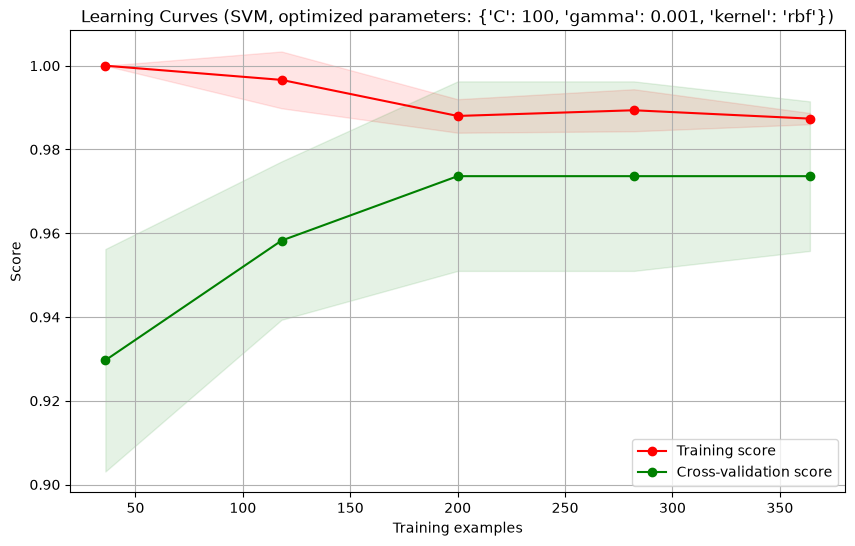

In [54]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [55]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

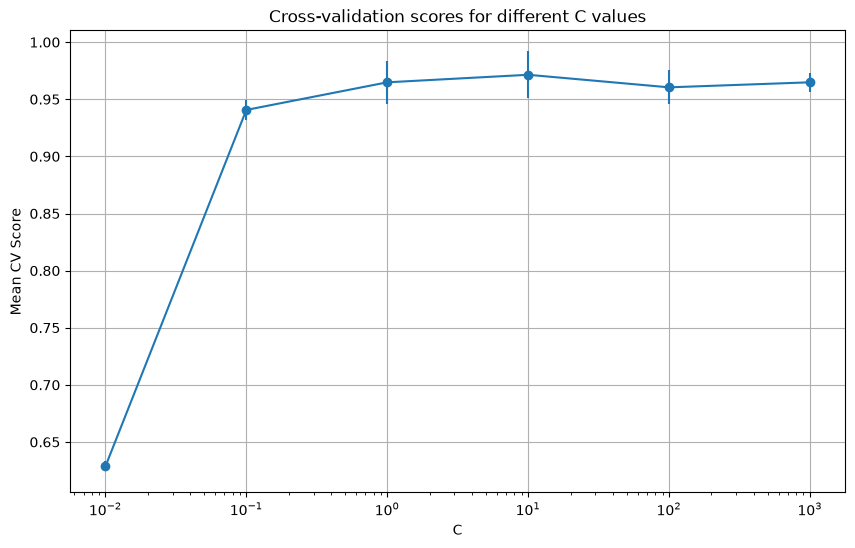

In [56]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

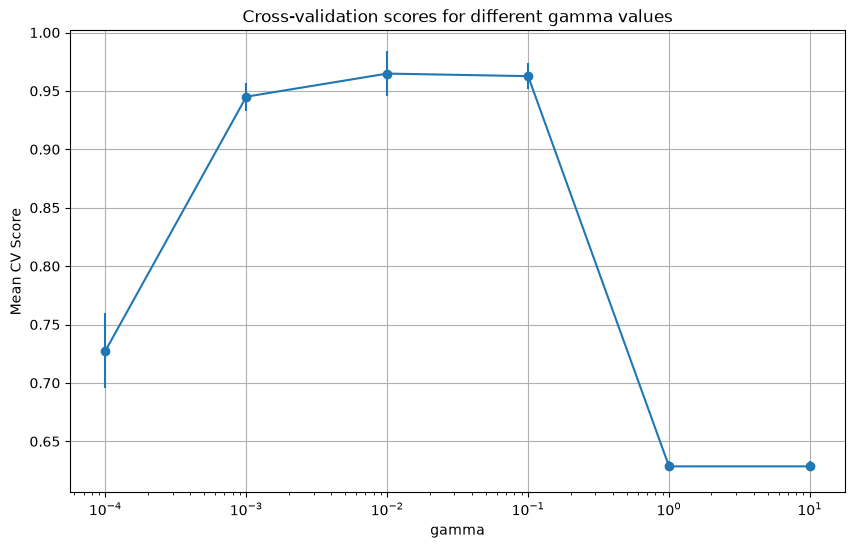

In [57]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [58]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [59]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [60]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [61]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [62]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [63]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....001957DCAEE90>, 'gamma': <scipy.stats....001957EE7AA50>, 'kernel': ['rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attribute

In [64]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [65]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [66]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [67]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [68]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy Execution Time (s)
0            Grid Search       0.973626       0.982456          15.283759
1          Random Search       0.971429       0.964912           0.947233
2  Bayesian Optimization       0.962637       0.956140          14.260584
3      Combined Approach       0.978022       0.982456               None


# Part 8: Visualizing hyperparameter importance

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [70]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

C:\Users\HP\miniconda3\envs\ds_learning\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",47.479208101335
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.015041969444183602
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [71]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [72]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [73]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

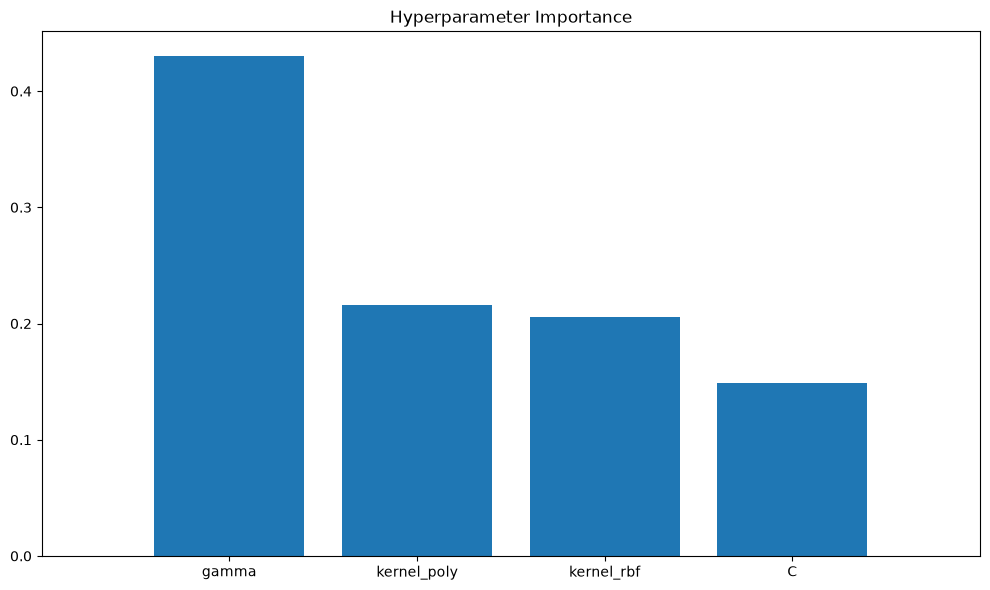

In [74]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [75]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

C:\Users\HP\AppData\Local\Temp\ipykernel_18300\878294285.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


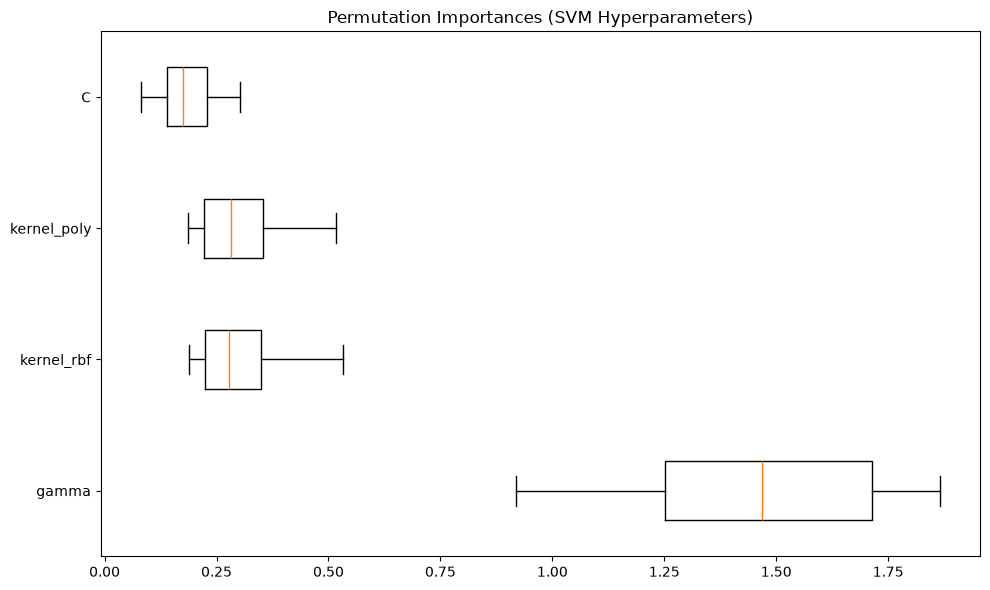

In [76]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            tick_labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [77]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [78]:
# ==============================================================================
# PART 1: SETUP AND DATA PREPARATION
# ==============================================================================
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

# Load the California housing dataset
# This dataset contains information about housing in California
# with features like median income, house age, average rooms, etc.
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Split the dataset into training and testing sets (80/20 split)
# YOUR CODE HERE
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Standardize the features using StandardScaler
# YOUR CODE HERE
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [79]:
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
# Import models
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# TODO: Create a dictionary of baseline models with default parameters
# Include Ridge Regression, SVR, Random Forest, and Gradient Boosting
# YOUR CODE HERE
base_line_models = {
    "ridge_reg": Ridge(alpha=1.0),    
    "random_forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "svr": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "gradient_boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)   
}
# TODO: Evaluate baseline models using 5-fold cross-validation
# Calculate and print mean and std of RMSE and R² for each model
# YOUR CODE HERE
def evaluate_model(model, X, y, cv, metric):
    start_time = time.time()
    
    # Run the cross validation
    scores = cross_val_score(model, X, y, cv=cv, scoring=metric, n_jobs=-1)
    
    time_taken = time.time() - start_time
    return scores, time_taken

resutls_baseline = {}
metrics = ['neg_mean_squared_error', 'r2']
for name, model in base_line_models.items():
    resutls_baseline[name] = {} 
    
    for metric in metrics:    
       score, time_taken = evaluate_model(model, x_train_scaled, y_train, cv=5, metric=metric)
       
       # RMSE -> MSE
       if metric == 'neg_mean_squared_error':
           score = np.sqrt(-score)
           metric_name = 'rmse'
       else:
           metric_name = 'r2'
           
       resutls_baseline[name][metric_name] = {
           'mean_score': np.mean(score),
           'std_score': np.std(score),
           'time_taken': time_taken
       }

# TODO: Visualize baseline model performance with a bar plot
# YOUR CODE HERE

In [80]:
resutls_baseline

{'ridge_reg': {'rmse': {'mean_score': np.float64(0.7205273313349767),
   'std_score': np.float64(0.0102800194474259),
   'time_taken': 0.13916254043579102},
  'r2': {'mean_score': np.float64(0.6114838842658133),
   'std_score': np.float64(0.006460016132780911),
   'time_taken': 0.12525510787963867}},
 'random_forest': {'rmse': {'mean_score': np.float64(0.5110747212575685),
   'std_score': np.float64(0.004476312303494867),
   'time_taken': 16.552436590194702},
  'r2': {'mean_score': np.float64(0.8044643365501658),
   'std_score': np.float64(0.005263663239924373),
   'time_taken': 16.842899799346924}},
 'svr': {'rmse': {'mean_score': np.float64(0.5930564076793442),
   'std_score': np.float64(0.010569708709117184),
   'time_taken': 22.220130681991577},
  'r2': {'mean_score': np.float64(0.7368140944246037),
   'std_score': np.float64(0.004814403027834735),
   'time_taken': 24.6135835647583}},
 'gradient_boosting': {'rmse': {'mean_score': np.float64(0.5340674642135211),
   'std_score': np.f

In [81]:
rmse_mean, r2_mean, model_name = [], [], []
for k in base_line_models.keys():
    model_name.append(k)
    rmse_mean.append(resutls_baseline[k]['rmse'].get('mean_score'))
    r2_mean.append(resutls_baseline[k]['r2'].get('mean_score'))


In [82]:
p_df = pd.DataFrame({
    'models': model_name,
    'rmse_mean': rmse_mean,
    'r2_mean': r2_mean
})

p_df

,models,rmse_mean,r2_mean
0,ridge_reg,0.720527,0.611484
1,random_forest,0.511075,0.804464
2,svr,0.593056,0.736814
3,gradient_boosting,0.534067,0.786548


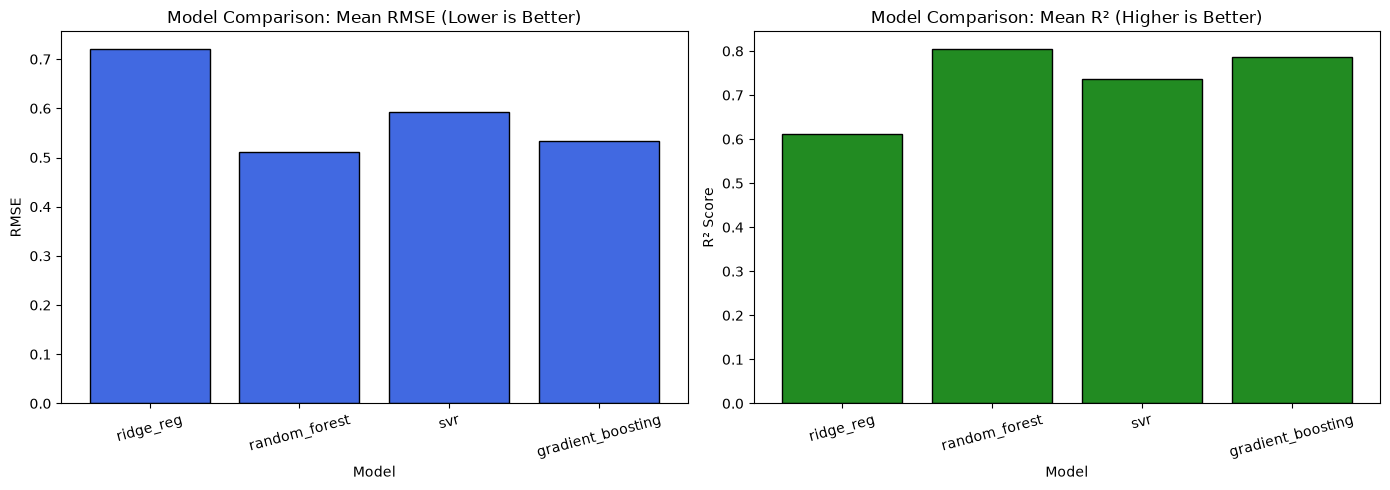

In [83]:
# Create a figure with 1 row and 2 columns
plt.figure(figsize=(14, 5))

#RMSE
plt.subplot(1, 2, 1)
plt.bar(p_df['models'], p_df['rmse_mean'], color='royalblue', edgecolor='black')
plt.title('Model Comparison: Mean RMSE (Lower is Better)')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.xticks(rotation=15)

#r2
plt.subplot(1, 2, 2)
plt.bar(p_df['models'], p_df['r2_mean'], color='forestgreen', edgecolor='black')
plt.title('Model Comparison: Mean R² (Higher is Better)')
plt.ylabel('R² Score')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [84]:
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING USING GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV

# TODO: Define parameter grids for each model
# Ridge: alpha values
# SVR: C, gamma, and kernel values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE
params_dict = {
"pg_ridge_reg" : {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
},

"pg_random_forest" : {
        'n_estimators':[50,100],
        'max_depth': [10, 20, None],
        'min_samples_split': [2,5],
},
    
"pg_svr" : {
    'C':[0.1],
    'gamma': [0.001,0.1,],
    'kernel': ['rbf', 'linear']
},



"pg_gradient_boosting": {
        'n_estimators':[50,100],
        'max_depth': [3, 5, None],
        'min_samples_split': [2,5],
        'learning_rate': [0.01, 0.1, 0.2]
}}

# TODO: Create a function that performs grid search for a given model and parameter grid
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def grid_search_util(model, p_grid, X=x_train_scaled, y=y_train): #hard coding data for now
    start_time = time.time()

    grid_search = GridSearchCV(
    estimator=model,
    param_grid=p_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='r2',
    return_train_score=True
    )

    grid_search.fit(X, y)

    grid_time = time.time() - start_time
    
    return ({
            'best_model': grid_search.best_estimator_, 
            'best_parameters': grid_search.best_params_,
            'best_score': round(grid_search.best_score_, 4),
            'time_taken': round(grid_time, 2)
        })

# TODO: Apply grid search to all models
# YOUR CODE HERE

results_collection = []
for model in base_line_models.keys():
    results = grid_search_util(base_line_models[model], p_grid=  params_dict.get('pg_'+model))
    print(f"best_parameters: {results.get('best_parameters')} -- best_score: {results.get('best_score')} -- time_taken: {results.get('time_taken')}")
    results_collection.append(results)
    
# TODO: Create a comparison table or visualization of grid search results
# YOUR CODE HERE

best_parameters: {'alpha': 0.001} -- best_score: 0.6115 -- time_taken: 0.21
best_parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100} -- best_score: 0.8045 -- time_taken: 96.43
best_parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'} -- best_score: 0.6877 -- time_taken: 145.58
best_parameters: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} -- best_score: 0.8264 -- time_taken: 259.41


In [88]:
results_collection

[{'best_model': Ridge(alpha=0.001),
  'best_parameters': {'alpha': 0.001},
  'best_score': np.float64(0.6115),
  'time_taken': 0.21},
 {'best_model': RandomForestRegressor(max_depth=20, random_state=42),
  'best_parameters': {'max_depth': 20,
   'min_samples_split': 2,
   'n_estimators': 100},
  'best_score': np.float64(0.8045),
  'time_taken': 96.43},
 {'best_model': SVR(C=0.1, gamma=0.1),
  'best_parameters': {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'},
  'best_score': np.float64(0.6877),
  'time_taken': 145.58},
 {'best_model': GradientBoostingRegressor(learning_rate=0.2, max_depth=5, random_state=42),
  'best_parameters': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_samples_split': 2,
   'n_estimators': 100},
  'best_score': np.float64(0.8264),
  'time_taken': 259.41}]

In [ ]:
# Create a figure with 1 row and 2 columns
plt.figure(figsize=(14, 5))

#RMSE
plt.subplot(1, 2, 1)
plt.bar(p_df['models'], p_df['rmse_mean'], color='royalblue', edgecolor='black')
plt.title('Model Comparison: Mean RMSE (Lower is Better)')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.xticks(rotation=15)

#r2
plt.subplot(1, 2, 2)
plt.bar(p_df['models'], p_df['r2_mean'], color='forestgreen', edgecolor='black')
plt.title('Model Comparison: Mean R² (Higher is Better)')
plt.ylabel('R² Score')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING USING RANDOM SEARCH
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# TODO: Define parameter distributions for each model
# Ridge: alpha values
# SVR: C, gamma values
# Random Forest: n_estimators, max_depth, min_samples_split
# Gradient Boosting: n_estimators, max_depth, learning_rate
# YOUR CODE HERE
params_dict_random = {
    "pg_ridge_reg": {
        'alpha': uniform(0.001, 1000)
    },

    "pg_random_forest": {
        'n_estimators': randint(50, 200),
        'max_depth': randint(5, 30),
        'min_samples_split': randint(2, 10),
    },
    
    "pg_svr": {
        'C': uniform(0.1, 3),
        'gamma': uniform(0.001, 0.2),
        'kernel': [ 'linear']
    },

    "pg_gradient_boosting": {
        'n_estimators': randint(50, 150),
        'max_depth': randint(3, 7), 
        'min_samples_split': randint(2, 10),
        'learning_rate': uniform(0.01, 0.2)
    }
}

# TODO: Create a function that performs random search for a given model and parameter distribution
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def randon_search_util(model, p_grid, X=x_train_scaled, y=y_train): #hard coding data for now
    start_time = time.time()

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=p_grid,  
        n_iter=20,                 
        cv=5,                 
        n_jobs=-1,
        verbose=0,
        scoring='r2',
        return_train_score=True,
        random_state=42          
    )

    random_search.fit(X,y)
    
    random_time = time.time() - start_time
    
    return ({
            'best_model': random_search.best_estimator_, 
            'best_parameters': random_search.best_params_,
            'best_score': round(random_search.best_score_, 4),
            'time_taken': round(random_time, 2)
        })


# TODO: Apply random search to all models with 20 iterations
# YOUR CODE HERE

results_collection_random = []
for model in base_line_models.keys():
    results = randon_search_util(base_line_models[model], p_grid=  params_dict_random.get('pg_'+model))
    print(f"best_parameters: {results.get('best_parameters')} -- best_score: {results.get('best_score')} -- time_taken: {results.get('time_taken')}")
    results_collection_random.append(results)

# TODO: Create a comparison table or visualization of random search results
# YOUR CODE HERE


best_parameters: {'alpha': np.float64(20.585494295802448)} -- best_score: 0.6114 -- time_taken: 5.24
best_parameters: {'max_depth': 19, 'min_samples_split': 4, 'n_estimators': 121} -- best_score: 0.8048 -- time_taken: 171.15


In [ ]:
results_collection_random

In [5]:
 # ==============================================================================
# PART 5: HYPERPARAMETER TUNING USING BAYESIAN OPTIMIZATION
# ==============================================================================
# Install scikit-optimize if not already installed
!pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# TODO: Define search spaces for each model using skopt's parameter types
# YOUR CODE HERE
search_spaces = {
    "Ridge": {
        "alpha": Real(0.1, 10.0, prior="log-uniform"),
    },
    "SVR": {
        "C": Real(1.0, 10.0, prior="log-uniform"),
        "gamma": Categorical(["scale", "auto"]),
        "kernel": Categorical(["rbf"]),
    },
    "Random Forest": {
        "n_estimators": Integer(50, 150),
        "max_depth": Integer(5, 20),
        "min_samples_split": Integer(2, 10),
    },
    "Gradient Boosting": {
        "n_estimators": Integer(50, 150),
        "max_depth": Integer(3, 10),
        "learning_rate": Real(0.01, 0.2, prior="log-uniform"),
    },
}

# TODO: Create a function that performs Bayesian optimization for a given model and search space
# The function should return the best model, best parameters, best score, and elapsed time
# YOUR CODE HERE
def perform_bayesian_search(model, search_space):
    start_time = time.time()

    bayes_search = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=20,
        cv=3,
        scoring="r2",
        random_state=42,
        n_jobs=-1,
    )
    bayes_search.fit(X_train, y_train)

    elapsed_time = time.time() - start_time
    return (
        bayes_search.best_estimator_,
        bayes_search.best_params_,
        bayes_search.best_score_,
        elapsed_time,
    )
# TODO: Apply Bayesian optimization to all models with 20 iterations
# YOUR CODE HERE
bayesian_results = []
best_models = {}

for name, model in base_line_models.items():
    best_model, best_params, best_score, elapsed_time = perform_bayesian_search(
        model, search_spaces[name]
    )

    best_models[name] = best_model
    bayesian_results.append({
        "Model": name,
        "Best Score": best_score,
        "Time (s)": elapsed_time,
        "Best Parameters": str(best_params),
    })
# TODO: Create a comparison table or visualization of Bayesian optimization results
# YOUR CODE HERE
bayesian_results_df = pd.DataFrame(bayesian_results)
print(bayesian_results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=bayesian_results_df, x="Model", y="Best Score")
plt.title("Bayesian Optimization Best R² Scores")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

NameError: name 'base_line_models' is not defined

In [3]:
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================

# TODO: Create a comprehensive comparison of all tuning methods
# Include metrics like best score, elapsed time, and improvement over baseline
# YOUR CODE HERE
baseline_scores = results_df[["Model", "R2"]].rename(
    columns={"R2": "Baseline Score"}
)
grid_scores = grid_results_df[["Model", "Best Score", "Time (s)"]].rename(
    columns={"Best Score": "Grid Score", "Time (s)": "Grid Time"}
)
random_scores = random_results_df[["Model", "Best Score", "Time (s)"]].rename(
    columns={"Best Score": "Random Score", "Time (s)": "Random Time"}
)
bayesian_scores = bayesian_results_df[
    ["Model", "Best Score", "Time (s)"]
].rename(columns={"Best Score": "Bayesian Score", "Time (s)": "Bayesian Time"})

# Merge all DataFrames on the common 'Model' column
comparison_df = (
    baseline_scores.merge(grid_scores, on="Model")
    .merge(random_scores, on="Model")
    .merge(bayesian_scores, on="Model")
)
# TODO: Visualize the comparison results
# Consider bar plots, scatter plots or heatmaps
# YOUR CODE HERE
comparison_df["Grid Improvement"] = (
    comparison_df["Grid Score"] - comparison_df["Baseline Score"]
)
comparison_df["Random Improvement"] = (
    comparison_df["Random Score"] - comparison_df["Baseline Score"]
)
comparison_df["Bayesian Improvement"] = (
    comparison_df["Bayesian Score"] - comparison_df["Baseline Score"]
)

print("Tuning Method Comparison")
print(comparison_df.to_string(index=False))

NameError: name 'results_df' is not defined

In [ ]:
# ==============================================================================
# PART 7: ANALYZE TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================

# TODO: Calculate efficiency metrics for each tuning method
# Efficiency = (improvement in score) / (time spent tuning)
# YOUR CODE HERE

# TODO: Analyze the relationship between number of hyperparameters and tuning efficiency
# YOUR CODE HERE

# Meta-learning: Predict which algorithm performs best based on a subset of data
# TODO: Create a function to extract dataset characteristics
# Examples: number of instances, number of features, feature statistics, etc.
# YOUR CODE HERE

# TODO: Generate multiple small datasets by sampling from the California housing data
# Extract characteristics and record best algorithm for each sample
# YOUR CODE HERE

# TODO: Train a classifier to predict the best algorithm based on dataset characteristics
# YOUR CODE HERE


In [ ]:
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================

# TODO: Create an ensemble of your best tuned models
# Use a simple averaging approach or a more sophisticated method
# YOUR CODE HERE

# TODO: Evaluate the ensemble on the test set
# Compare its performance with individual models
# YOUR CODE HERE

In [ ]:
# ==============================================================================
# PART 10: CONCLUSION AND REPORTING
# ==============================================================================

# TODO: Summarize your findings
# Which model performed best?
# Which tuning method was most efficient?
# Was the ensemble better than individual models?
# What did you learn about hyperparameter spaces?
# YOUR ANSWER HERE

In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file